In [25]:
import pandas as pd
import requests
import warnings
warnings.filterwarnings("ignore")

# API URL
url = "https://survey.ifkw.lmu.de/Referat_MP/?act=0hoYBIxGYBmwcr5ofdYX5XI3"

# JSON-Daten von der API abrufen
response = requests.get(url)

# JSON in DataFrame konvertieren
df = pd.DataFrame(response.json())
df_var = df["data"][4:]

df_var

C29    {'CASE': 29, 'QUESTNNR': 'base', 'MODE': 'inte...
C30    {'CASE': 30, 'QUESTNNR': 'base', 'MODE': 'inte...
C31    {'CASE': 31, 'QUESTNNR': 'base', 'MODE': 'inte...
C32    {'CASE': 32, 'QUESTNNR': 'base', 'MODE': 'inte...
C33    {'CASE': 33, 'QUESTNNR': 'base', 'MODE': 'inte...
C34    {'CASE': 34, 'QUESTNNR': 'base', 'MODE': 'inte...
C35    {'CASE': 35, 'QUESTNNR': 'base', 'MODE': 'inte...
C36    {'CASE': 36, 'QUESTNNR': 'base', 'MODE': 'inte...
C37    {'CASE': 37, 'QUESTNNR': 'base', 'MODE': 'inte...
C38    {'CASE': 38, 'QUESTNNR': 'base', 'MODE': 'inte...
C39    {'CASE': 39, 'QUESTNNR': 'base', 'MODE': 'inte...
C41    {'CASE': 41, 'QUESTNNR': 'base', 'MODE': 'inte...
C42    {'CASE': 42, 'QUESTNNR': 'base', 'MODE': 'inte...
C43    {'CASE': 43, 'QUESTNNR': 'base', 'MODE': 'inte...
C44    {'CASE': 44, 'QUESTNNR': 'base', 'MODE': 'inte...
Name: data, dtype: object

In [26]:

liste_df = []

data = {}

for n in range( len(df_var)):
    data = {}
    data["Zeitung"]        =  df_var[n]["EF01_01"]
    data["Fernsehen"]      =  df_var[n]["EF01_02"]
    data["Soziale-Medien"] =  df_var[n]["EF01_03"]
    data["LLMs"]           =  df_var[n]["EF01_04"]
    liste_df.append(data)


df_numeric = pd.DataFrame(liste_df)
df_numeric = df_numeric[(df_numeric >= 0).all(axis=1)]
# Index neu starten bei Person 1
df_numeric.index = [f"Person {i+1}" for i in range(len(df_numeric))]

df_numeric

,Zeitung,Fernsehen,Soziale-Medien,LLMs
Person 1,4,3,2,3
Person 2,5,3,3,1
Person 3,4,4,3,3
Person 4,5,4,3,3
Person 5,4,3,3,2
Person 6,3,3,2,2
Person 7,5,4,1,2
Person 8,5,4,1,3
Person 9,4,3,2,3
Person 10,4,3,3,3


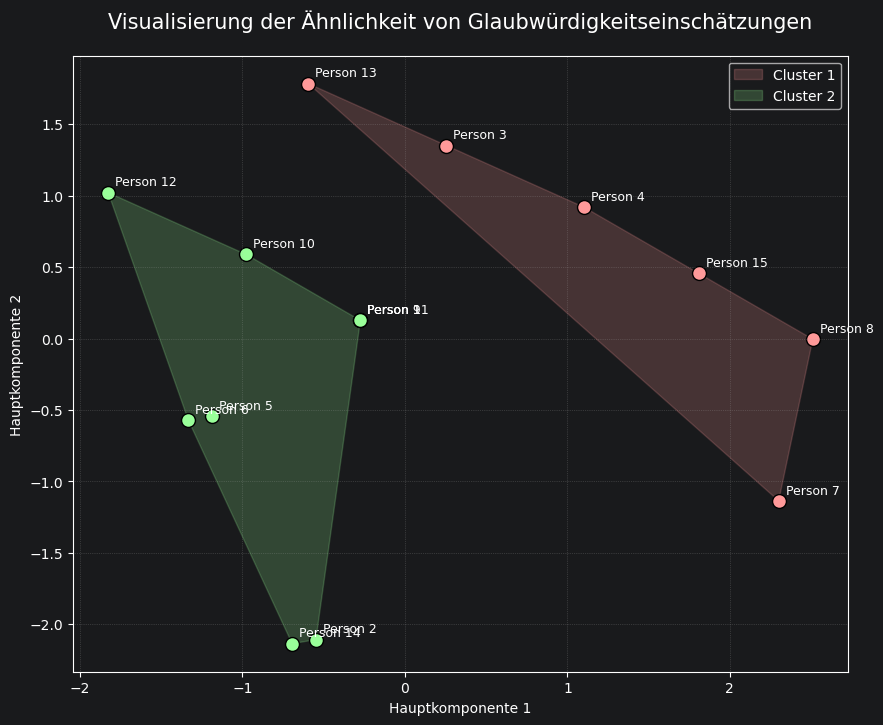

In [28]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial import ConvexHull
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# 1. Cluster berechnen
n_clusters = 2
cluster = AgglomerativeClustering(n_clusters=n_clusters)
labels = cluster.fit_predict(df_scaled)

# 2. PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 8))
colors = ['#FF9999', '#99FF99', '#9999FF']

# 3. Inseln (Hüllen) zeichnen
for i in range(n_clusters):
    points = coords[labels == i]
    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices,0], points[hull.vertices,1],
                 c=colors[i], alpha=0.2, label=f"Cluster {i+1}")

    plt.scatter(points[:, 0], points[:, 1], c=colors[i], edgecolors='black', s=100)

# Namen der Personen
for i, name in enumerate(df_numeric.index):
    plt.annotate(name, (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Reduzierte, ehrliche Beschriftung
plt.title("Visualisierung der Ähnlichkeit von Glaubwürdigkeitseinschätzungen", fontsize=15, pad=20)
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

In [29]:
# Cluster-Labels zum DataFrame hinzufügen
df_numeric['Cluster'] = labels + 1

cluster_profile = df_numeric.groupby('Cluster').mean()
print("Durchschnittliche Glaubwürdigkeitswerte pro Cluster:")
display(cluster_profile)

Durchschnittliche Glaubwürdigkeitswerte pro Cluster:


,Zeitung,Fernsehen,Soziale-Medien,LLMs
Cluster,,,,
1,4.500000,4.0,2.166667,2.833333
2,3.888889,3.0,2.444444,2.333333


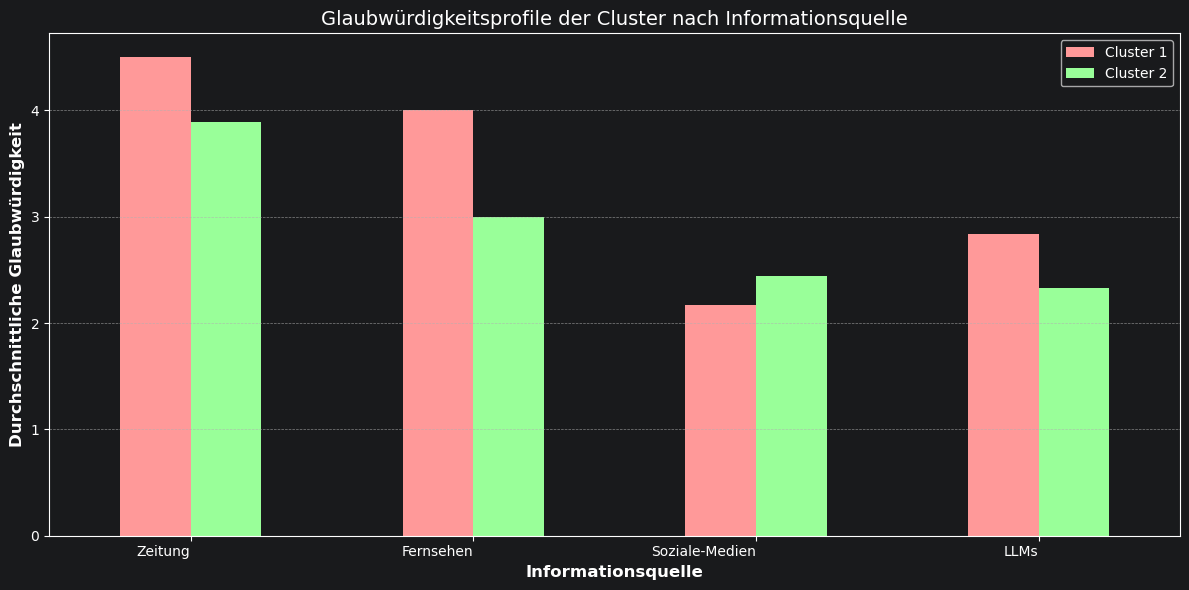

In [30]:
import matplotlib.pyplot as plt

cluster_profile.T.plot(kind='bar', figsize=(12, 6), color=['#FF9999', '#99FF99', '#9999FF'])
plt.title("Glaubwürdigkeitsprofile der Cluster nach Informationsquelle", fontsize=14)
plt.ylabel("Durchschnittliche Glaubwürdigkeit", fontsize=12, fontweight='bold')
plt.xlabel("Informationsquelle", fontsize=12, fontweight='bold')
plt.legend([f"Cluster {i+1}" for i in range(len(cluster_profile))]) # Dynamische Legende
plt.xticks(rotation=0, ha='right') # Right alignment for rotated labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()